In [1]:
# Day46_NLP_text_processing
15-may-25

In [8]:
import pandas as pd
import numpy as np

In [10]:
corpus = [
     'The car is driven on the road',
     'The truck is driven on the highway',     
 ]

# 46.1 Bag of words

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

## BOW - Using unigram

In [16]:
vectorizer=CountVectorizer( ngram_range=(1, 1))
ngram=vectorizer.fit_transform(corpus)

In [18]:
print(ngram.toarray())

[[1 1 0 1 1 1 2 0]
 [0 1 1 1 1 0 2 1]]


In [20]:
ngram_vocabulary=vectorizer.vocabulary_
ngram_vocabulary

{'the': 6,
 'car': 0,
 'is': 3,
 'driven': 1,
 'on': 4,
 'road': 5,
 'truck': 7,
 'highway': 2}

## BOW - Using Bigram

In [23]:
vectorizer=CountVectorizer( ngram_range=(2, 2))
bigram=vectorizer.fit_transform(corpus)

In [25]:
print(bigram.toarray())

[[1 1 1 1 1 0 1 0 0]
 [0 1 1 1 0 1 0 1 1]]


In [27]:
ngram_vocabulary=vectorizer.vocabulary_
ngram_vocabulary

{'the car': 4,
 'car is': 0,
 'is driven': 2,
 'driven on': 1,
 'on the': 3,
 'the road': 6,
 'the truck': 7,
 'truck is': 8,
 'the highway': 5}

In [29]:
## BOW - Using range

In [31]:
vectorizer=CountVectorizer( ngram_range=(1, 2))
rangegram=vectorizer.fit_transform(corpus)

In [33]:
print(rangegram.toarray())

[[1 1 1 1 0 1 1 1 1 1 2 1 0 1 0 0 0]
 [0 0 1 1 1 1 1 1 1 0 2 0 1 0 1 1 1]]


In [35]:
rangegram_vocabulary=vectorizer.vocabulary_
rangegram_vocabulary

{'the': 10,
 'car': 0,
 'is': 5,
 'driven': 2,
 'on': 7,
 'road': 9,
 'the car': 11,
 'car is': 1,
 'is driven': 6,
 'driven on': 3,
 'on the': 8,
 'the road': 13,
 'truck': 15,
 'highway': 4,
 'the truck': 14,
 'truck is': 16,
 'the highway': 12}

# 46.2) TF - IDF

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [40]:
tf_vectorizer=TfidfVectorizer(ngram_range=(1, 1))
tfidf=tf_vectorizer.fit_transform(corpus)
tfidf_df=pd.DataFrame(tfidf.toarray())

In [42]:
tfidf_df.head()

,0,1,2,3,4,5,6,7
0,0.424717,0.30219,0.000000,0.30219,0.30219,0.424717,0.60438,0.000000
1,0.000000,0.30219,0.424717,0.30219,0.30219,0.000000,0.60438,0.424717


# 46.3) Lets create classification model

In [45]:
spamham=pd.read_csv('smsspamcollection.csv', sep='\t')
spamham.head()

,label,message,length,punct
0,ham,"Go until jurong point, crazy.. Available only ...",111,9
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,6
3,ham,U dun say so early hor... U c already then say...,49,6
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,2


- lets split into train test

In [48]:
x=spamham['message']
y=spamham['label']
x.shape,y.shape

((5572,), (5572,))

In [50]:
from sklearn.model_selection import train_test_split

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.33,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((3733,), (1839,), (3733,), (1839,))

- lets convert text into number by using BOW(any one method can be used BOW or tfidf)

In [55]:
bow_vectorizer=CountVectorizer( ngram_range=(1, 1))
# Vectors created with TF-IDF
bow_ngram_vctrzr=bow_vectorizer.fit_transform(x_train)

In [56]:
bow_ngram_vctrzr.shape
# 7082 number of unique words
# 7082 number of rows

(3733, 7082)

- Convert to numeric using TF-IDF

In [60]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [62]:
spam_tf_vectorizer=TfidfVectorizer(ngram_range=(1, 1))

spam_tfidf=spam_tf_vectorizer.fit_transform(x_train)

spam_tfidf_df=pd.DataFrame(spam_tfidf.toarray())
print(spam_tfidf_df)

      0     1     2     3     4     5     6     7     8     9     ...  7072  \
0      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
1      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
2      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
3      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
4      0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
...    ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  ...   ...   
3728   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
3729   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
3730   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
3731   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   
3732   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  ...   0.0   

      7073  7074  7075  7076  7077  7078  7079  708

In [63]:
- Create classification model

SyntaxError: invalid syntax (2359610951.py, line 1)

In [66]:
from sklearn.svm import LinearSVC

In [68]:
linearSVC=LinearSVC()
linearSVC.fit(spam_tfidf,y_train)

LinearSVC()

In [70]:
predictions = linearSVC.predict(spam_tfidf)
predictions

array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'], dtype=object)

# Pipeline - In real time rather than individual step we we will be using pipeline

In [90]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix

In [75]:
txt_pipeline=Pipeline([('tfidf',TfidfVectorizer()),
                      ('clf',RandomForestClassifier())])

In [77]:
txt_pipeline.fit(x_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', RandomForestClassifier())])

- Evaluate the model - for train data

In [84]:
y_hat_train=txt_pipeline.predict(x_train)

In [88]:
metrics.accuracy_score(y_train,y_hat_train)

1.0

In [96]:
train_cm=confusion_matrix(y_train,y_hat_train)
print(train_cm)

[[3232    0]
 [   0  501]]


In [ ]:
- Evaluate the model - for test data

In [98]:
y_hat_test=txt_pipeline.predict(x_test)

In [100]:
metrics.accuracy_score(y_test,y_hat_test)

0.9820554649265906

In [102]:
test_cm=confusion_matrix(y_test,y_hat_test)
print(test_cm)

[[1593    0]
 [  33  213]]


# Preprocessing

In [13]:
#!pip install -U spacy

In [15]:
#!python -m spacy download en_core_web_sm

In [21]:
import spacy

# Load English model
nlp = spacy.load("en_core_web_sm")

# Example text
text = "Apple is looking at buying U.K. startup for $1 billion."

# Process the text
doc = nlp(text)

# Tokenization and basic analysis
for token in doc:
   print(f"{token.text:<12} | POS: {token.pos_:<10} | Lemma: {token.lemma_}")
#print(token.text)

Apple        | POS: PROPN      | Lemma: Apple
is           | POS: AUX        | Lemma: be
looking      | POS: VERB       | Lemma: look
at           | POS: ADP        | Lemma: at
buying       | POS: VERB       | Lemma: buy
U.K.         | POS: PROPN      | Lemma: U.K.
startup      | POS: VERB       | Lemma: startup
for          | POS: ADP        | Lemma: for
$            | POS: SYM        | Lemma: $
1            | POS: NUM        | Lemma: 1
billion      | POS: NUM        | Lemma: billion
.            | POS: PUNCT      | Lemma: .


In [33]:
nlp.pipeline

[('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x2056501bad0>),
 ('tagger', <spacy.pipeline.tagger.Tagger at 0x2056501b410>),
 ('parser', <spacy.pipeline.dep_parser.DependencyParser at 0x20564f4bb50>),
 ('attribute_ruler',
  <spacy.pipeline.attributeruler.AttributeRuler at 0x20559512bd0>),
 ('lemmatizer', <spacy.lang.en.lemmatizer.EnglishLemmatizer at 0x20566491d10>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x20564f4b7d0>)]

# Wordcloud

In [31]:
!pip install numpy

In [33]:
!pip install wordcloud

In [35]:
from PIL import Image
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import numpy as np

In [39]:
# Returns a string
dataset = open("modi.txt", "r").read()
dataset = dataset.lower()
#dataset

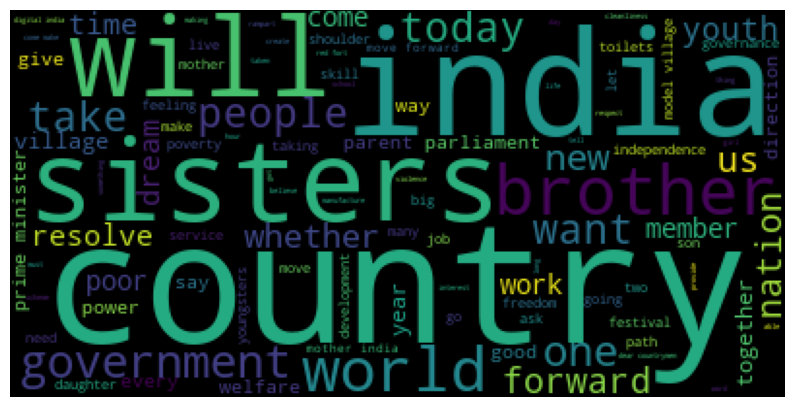

In [41]:
plt.figure(figsize=(10,6))

cloud = WordCloud(background_color = "black", max_words = 100,  stopwords = set(STOPWORDS))
cloud.generate(dataset)
#cloud.to_file("wordCloud.png")
plt.axis("off")
plt.imshow(cloud)

In [45]:
maskArray = np.array(Image.open("modi.png"))
cloud = WordCloud(background_color = "white", max_words = 400, mask = maskArray, stopwords = set(STOPWORDS))

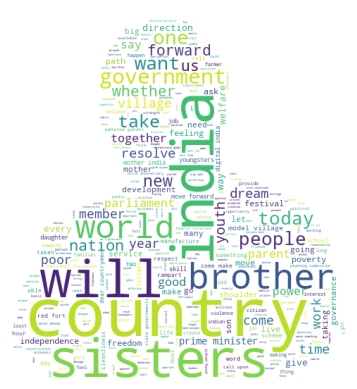

In [47]:
cloud.generate(dataset)
cloud.to_file("wordCloud.png")
plt.axis("off")
plt.imshow(cloud)
#plt.show()

In [23]:
# pip install --upgrade numpy pandas matplotlib scipy scikit-learn wordcloud

In [25]:
#!pip uninstall numpy -y
#!pip install numpy

In [27]:
#!pip uninstall scipy -y
#!pip install scipy

In [29]:
#!pip uninstall wordcloud -y
#!pip install wordcloud

In [31]:
#!conda update numpy
#!conda update --all